# Base de données

In [2]:
#initialisation 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
#import contextily as ctx      #marchait pas
import seaborn as sns          #ajout par rapport au main

df = pd.read_csv("../output/df_modele_musees.csv")
df.head()

,id_patrimostat,id_museofile,dateappellation,ferme,anneefermeture,ville,codeInseeCommune,annee,payant,gratuit,...,annee_creation,latitude,longitude,total_frequentation,age_musee,age_musee_missing,total_t_1,croissance_total,has_excel,est_idf
0,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2014,1865.0,2685.0,...,1960.0,48.410166,7.451102,4550.0,54.0,0,NaN,NaN,1,0
1,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2015,1874.0,1934.0,...,1960.0,48.410166,7.451102,3808.0,55.0,0,4550.0,-0.163077,1,0
2,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2016,1705.0,1409.0,...,1960.0,48.410166,7.451102,3114.0,56.0,0,3808.0,-0.182248,1,0
3,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2017,1163.0,1281.0,...,1960.0,48.410166,7.451102,2444.0,57.0,0,3114.0,-0.215157,1,0
4,6702101,M0001,01/02/2003,NON,NaN,BARR,67021,2018,1249.0,2341.0,...,1960.0,48.410166,7.451102,3590.0,58.0,0,2444.0,0.468903,1,0


## Statistiques descriptives

In [3]:
#Aperçu du dataframe : une ligne = un musée pour une année
#df.info()

#Stat desc sur le total de fréquentation
df["total"].describe()

count    1.124800e+04
mean     5.018695e+04
std      3.477633e+05
min      0.000000e+00
25%      2.029500e+03
50%      8.481000e+03
75%      2.650125e+04
max      1.010596e+07
Name: total, dtype: float64

L'écart-type est très grand, ce qui signifie qu'il y a une forte hétérogénéité entre les musées. La médiane est de 8 481 visiteurs et la moyenne de 50 186 visiteurs, ce qui nous montre que quelques musées connus concentrent la majorité des visites.

## Représentation géographique

In [ ]:
#initialisation de la sous partie 
#jsp quoi mettre

In [24]:
#CARTE REPARTITION DES MUSEES
# ça marche pas perso
from cartiflette import carti_download
#carte des musées en FR métro
#Filtre France métropolitaine sur les points
mask_metropole = (
    gdf_points.geometry.y.between(41, 52) &   # latitude
    gdf_points.geometry.x.between(-6, 10)     # longitude
)
gdf_points_metropole = gdf_points[mask_metropole].copy()

#Télécharger la carte des régions
france = carti_download(
    values=["France"],
    crs=4326,
    borders="REGION",
    vectorfile_format="geojson",
    simplification=50,
    filter_by="FRANCE_ENTIERE",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022
)

# garder seulement la métropole
france = france.loc[france["INSEE_REG"] > 10]

#Tracer
fig, ax = plt.subplots(figsize=(7, 9))

# fond de carte
france.plot(ax=ax, color="whitesmoke", edgecolor="black")

# taille des points bornée (évite la grosse tache)
ms = np.clip(gdf_points_metropole["total"] / 100000, 3, 20)

gdf_points_metropole.plot(
    ax=ax,
    markersize=ms,
    color="red",
    alpha=0.6
)

ax.set_title("Musées en France métropolitaine")
ax.set_axis_off()
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'cartiflette'

*quelque chose à dire de la carte ? je pense pas ?*

In [25]:
#CARTE FREQUENCE MOYENNE
# ça marche pas perso
import mapclassify


#Fréquentation moyenne par musée dans chaque région
df_region = (
    df.groupby("region")
      .agg(
          visites_totales=("total", "sum"),
          nb_musees=("id_museofile", "nunique")
      )
)

df_region["freq_par_musee"] = df_region["visites_totales"] / df_region["nb_musees"]
df_region = df_region.reset_index()

#Fonction de normalisation des noms de régions
def normalize_name(s):
    """Met les noms de région en minuscule, enlève les espaces et harmonise les tirets."""
    if pd.isna(s):
        return np.nan
    s = str(s).lower()
    s = s.replace("–", "-").replace("—", "-")  # différents tirets → '-'
    s = s.replace("  ", " ")
    return s.strip()

#réer region_clean côté données et côté carte
df_region["region_clean"] = df_region["region"].apply(normalize_name)
france["region_clean"] = france["LIBELLE_REGION"].apply(normalize_name)

#Corrections manuelles sur quelques régions
mapping = {
    "pays-de-la-loire": "pays de la loire",
    "provence-alpes-côte-d'azur": "provence-alpes-côte d'azur",
    "territoires et départements d'outre-mer": np.nan,  # on ignore, pas dans la carte
}

df_region["region_clean"] = df_region["region_clean"].replace(mapping)

#On enlève les lignes sans région métropolitaine
df_region = df_region.dropna(subset=["region_clean"])

#Jointure
france_reg = france.merge(
    df_region[["region_clean", "freq_par_musee"]],
    on="region_clean",
    how="left"
)

#On garde uniquement les régions avec données (métropole)
france_reg_clean = france_reg[france_reg["freq_par_musee"].notna()].copy()

#Classification en quantiles
scheme = mapclassify.Quantiles(france_reg_clean["freq_par_musee"], k=5)

#Tracé de la choroplèthe
fig, ax = plt.subplots(figsize=(10, 10))

france_reg_clean.plot(
    column="freq_par_musee",
    cmap="OrRd",
    legend=True,
    edgecolor="grey",
    linewidth=0.6,
    scheme="Quantiles",   # ✔️ c’est ici qu’on met 'Quantiles'
    k=5,                  # ✔️ nb de classes
    ax=ax
)

#Légende qualitative
labels = ["Très faible", "Faible", "Moyenne", "Élevée", "Très élevée"]

leg = ax.get_legend()
leg.set_title("Niveau de fréquentation\n(moyenne par musée)")

for lbl, txt in zip(labels, leg.texts):
    txt.set_text(lbl)

ax.set_title("Fréquentation moyenne par musée et par région (quantiles)", 
             fontsize=14, pad=15)
ax.set_axis_off()

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'mapclassify'

*dire qqc sur la carte peut être ?*

## Analyse globale de la fréquentation

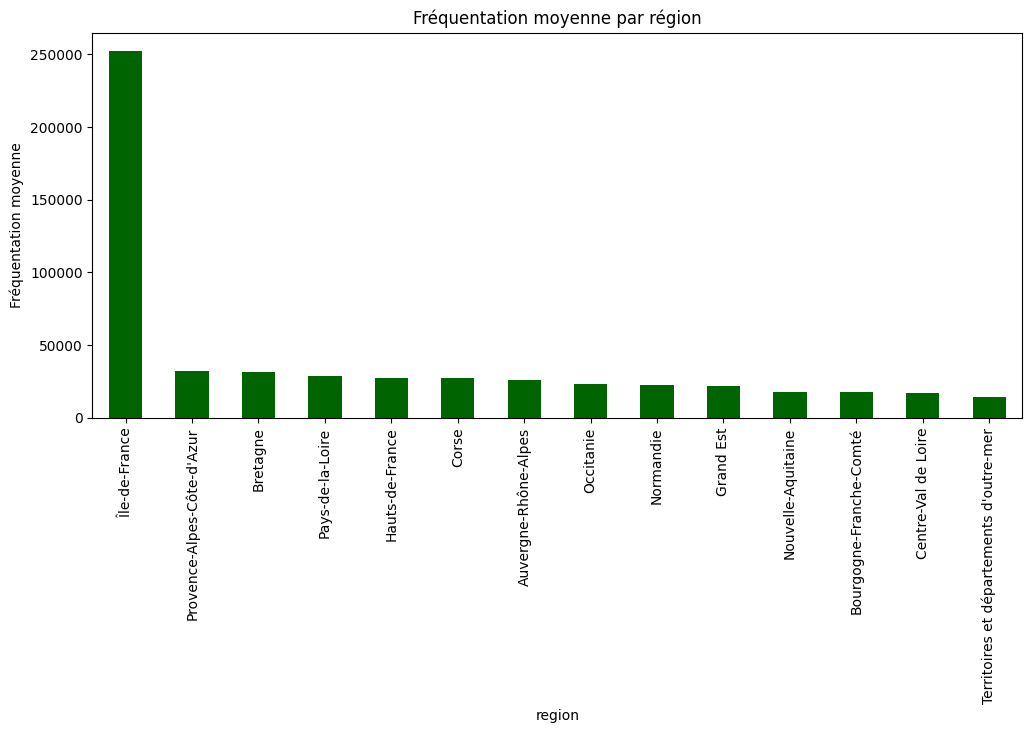

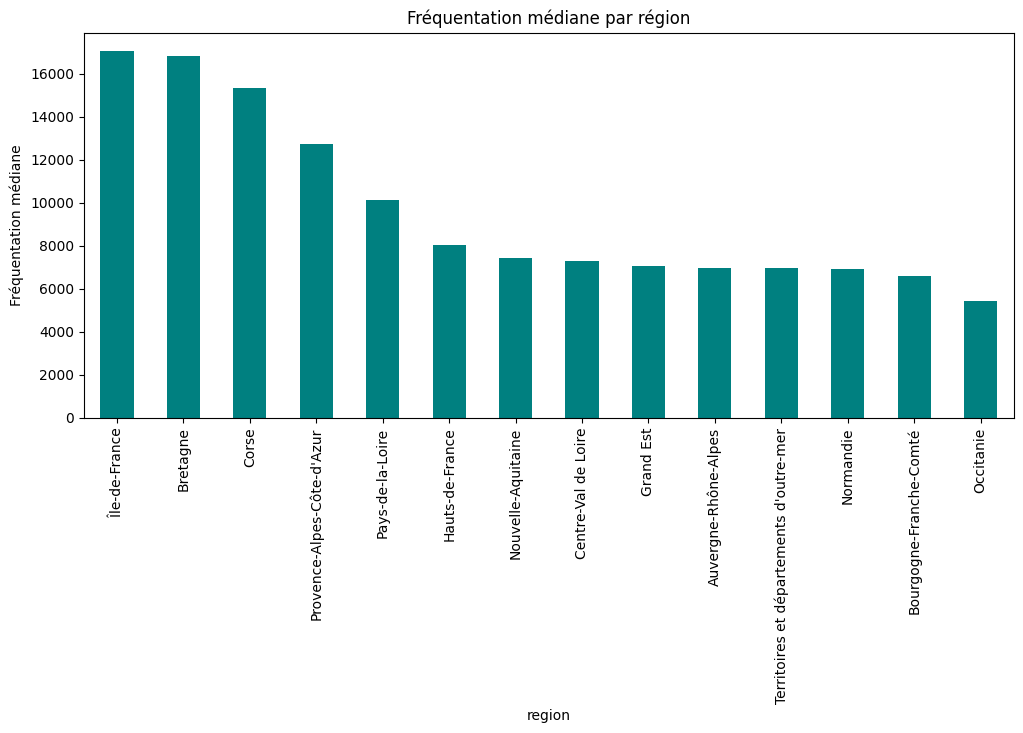

In [ ]:
#FREQUENTATION MOYENNE PAR REGION
df_reg = (
    df.groupby("region")["total"]
      .mean()
      .sort_values(ascending=False)
)

df_reg.plot(kind="bar", figsize=(12,5), color="darkgreen")
plt.title("Fréquentation moyenne par région")
plt.ylabel("Fréquentation moyenne")
plt.show()

df_reg = (
    df.groupby("region")["total"]
      .median()
      .sort_values(ascending=False)
)

#FRÉQUENTATION MÉDIANE PAR RÉGION
df_reg.plot(kind="bar", figsize=(12,5), color="teal")
plt.title("Fréquentation médiane par région")
plt.ylabel("Fréquentation médiane")
plt.show()

Dans le premier graphique, on voit que l'Île-de-France concentre les musées qui attirent le plus de visiteurs, ce qui rend le graphique peu pertinent pour effectuer des comparaisons. Néanmoins, la médiane permet une meilleure interprétation des tendances régionales en limitant l'importance des valeurs aberrantes. On observe ici que l'Île-de-France, la Bretagne et la Corse possèdent une fréquentation médiane similaire.

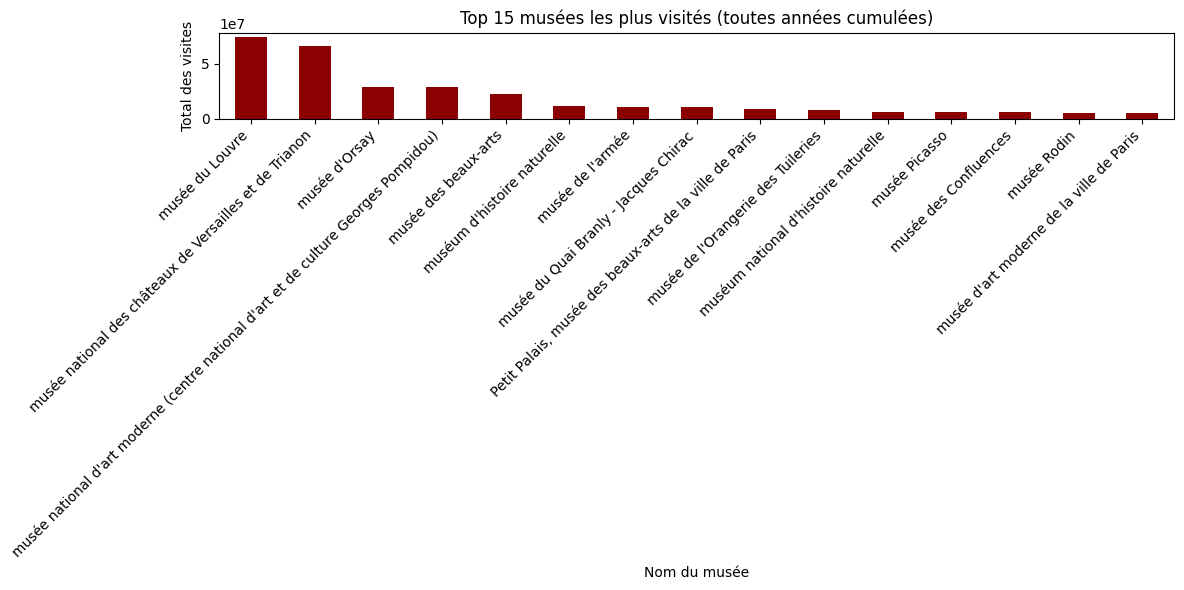

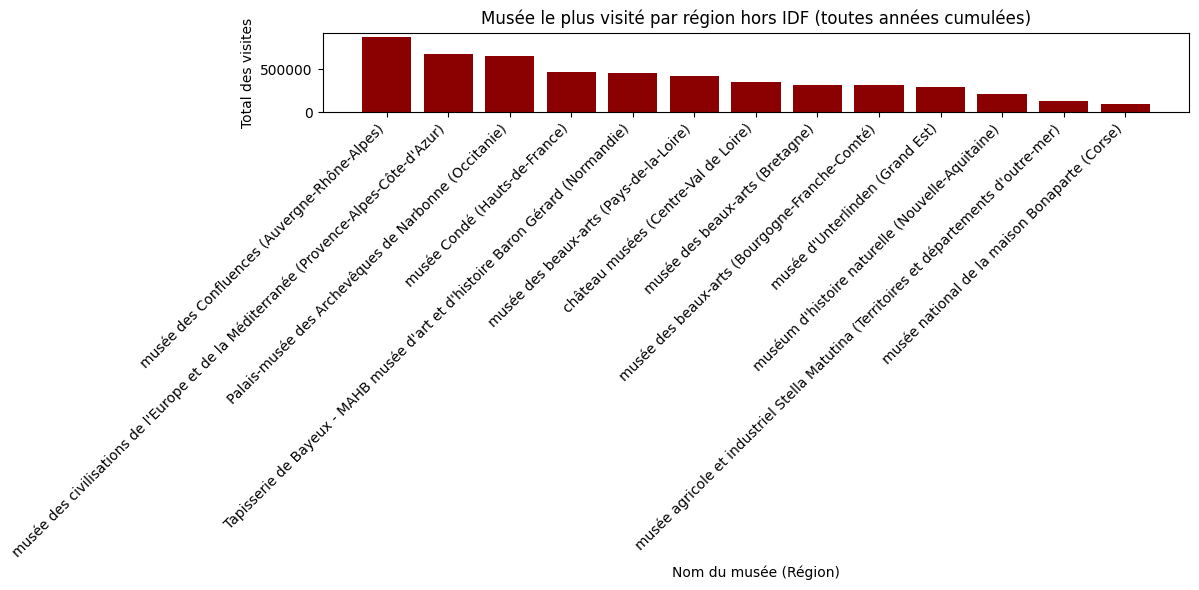

In [ ]:
#TOP 15 DES MUSÉES LES PLUS VISITÉS
top_musees = (
    df.groupby("nom_officiel")["total"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))
top_musees.plot(kind="bar", color="darkred")
plt.title("Top 15 musées les plus visités (toutes années cumulées)")
plt.ylabel("Total des visites")
plt.xlabel("Nom du musée")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#MUSÉE LE PLUS VISITÉ PAR RÉGION
df_sans_idf = df[df["region"] != "Île-de-France"]

max_region = df_sans_idf.groupby("region")["total"].idxmax()   #plus visité par région
top_musees_region = df_sans_idf.loc[max_region].sort_values("total", ascending=False)
top_musees_region["label"] = top_musees_region["nom_officiel"] + " (" + top_musees_region["region"] + ")"

plt.figure(figsize=(12,6))
plt.bar(top_musees_region["label"], top_musees_region["total"], color="darkred")
plt.title("Musée le plus visité par région hors IDF (toutes années cumulées)")
plt.ylabel("Total des visites")
plt.xlabel("Nom du musée (Région)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Seul le musée des Confluences de Lyon parvient à concurrencer les musées parisiens pour se hisser dans le top 15 français. 
*phrase sur le type des musées qui sont dans le top 15*
*phrase sur le type des musées les plus visités dans les régions*

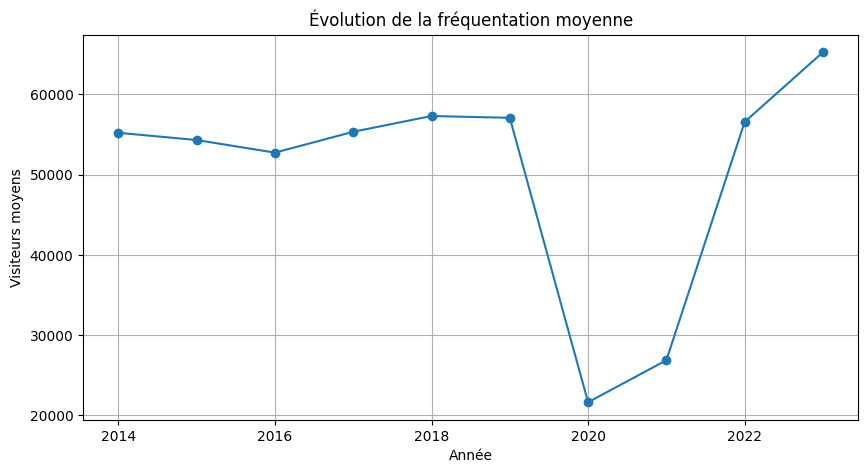

In [19]:
#ÉVOLUTION DE LA FRÉQUENTATION MOYENNE
df_year = df.groupby("annee")["total"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(df_year["annee"], df_year["total"], marker="o")
plt.title("Évolution de la fréquentation moyenne")
plt.xlabel("Année")
plt.ylabel("Visiteurs moyens")
plt.grid(True)
plt.show()

Alors que la fréquentation pré-COVID stagnait autour de 55 000 visiteurs par an (*millions ?? -> si oui, rajouter dans le graph*), on observe d'abord un retour à la normale en 2022 puis une hausse en 2023. *interprétation ?*

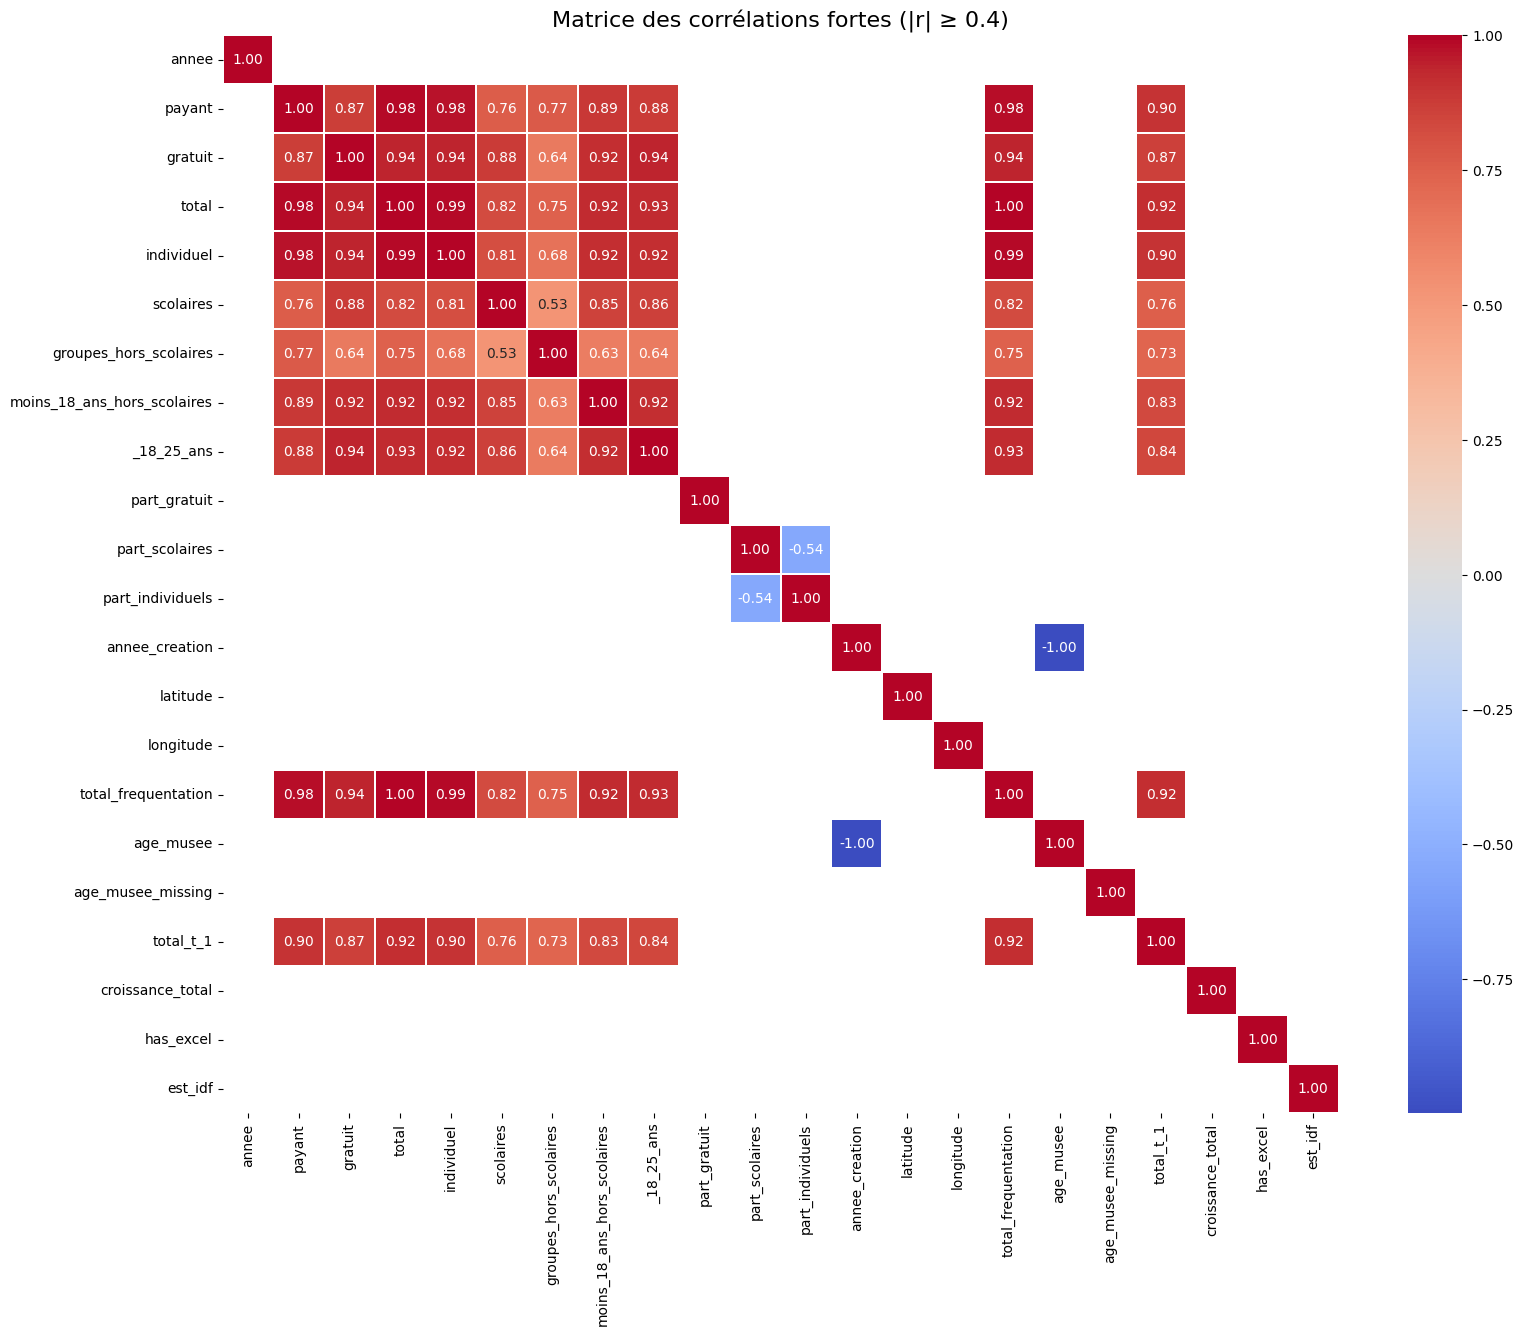

In [23]:
#MATRICE DES CORRÉLATIONS

# Sélectionner uniquement les colonnes numériques
num_cols = df.select_dtypes(include='number') 

# Matrice de corrélation fortes (au moins 0.4 ou au plus -0.4)
corr = num_cols.corr()
strong_corr = corr.where(corr.abs() >= 0.4)

plt.figure(figsize=(18, 14))
sns.heatmap(
    strong_corr,
    cmap="coolwarm",
    annot=True,       
    center=0,
    linewidths=0.3,
    fmt=".2f",
)

plt.title("Matrice des corrélations fortes (|r| ≥ 0.4)", fontsize=16)
plt.show()

*Je suis pas bien certaine de comment ça s'interprète cette folie*

## Analyse des publics

In [ ]:
#CRÉER LES CATÉGORIES 
#bcp de NaN et catégories diff, trier

In [27]:
#Stat desc sur les différentes parts
print(df[["part_gratuit","part_scolaires","part_individuels"]].describe())

       part_gratuit  part_scolaires  part_individuels
count   9835.000000     8533.000000       8475.000000
mean       0.546975        0.150406          0.746921
std        0.312579        0.152455          0.227458
min        0.000000        0.000000          0.000000
25%        0.290885        0.038792          0.651140
50%        0.533213        0.109170          0.797020
75%        0.813839        0.215014          0.895077
max        1.000000        1.896552          6.773839


En moyenne, les entrées gratuites représentent 54.69% des entrées totales d'un musée. *faire un commentaire sur l'accès à la culture ?*
En moyenne, les groupes scolaires représentent 15.04% des entrées totales d'un musée. L'écart-type étant de faible (0.15), on comprend que cette moyenne ne varie que très peu entre les musées.
*le total n'est pas égal à 1, problème ?*